In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, chi2
import json
import time


In [4]:
df = pkl.load(open('project8.pkl', 'rb'))
df.shape

(2027, 19)

### Preprocessing

In [5]:
df["preprocessed_text"] = df["self_text"].apply(lambda x: x.lower())

In [6]:
stop_words = set(stopwords.words('english'))
df["tokenized_text"] = df["preprocessed_text"].apply(lambda x: word_tokenize(x))
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in stop_words])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 


In [7]:
common_words = set()
with open ("common_words.txt", "r") as f:
    for line in f:
        common_words.add(line.strip())


In [8]:
#after we have made a list of common words, we can remove them from the tokenized text
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in common_words])

In [9]:
top_5000_words = set()
with open("top_5000_words.txt", "r") as f:
    for line in f:
        top_5000_words.add(line.strip())
        
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word in top_5000_words])
#remove empty lists
df = df[df["preprocessed_text"].map(lambda d: len(d)) > 5]
df["preprocessed_text"].head()

0    [yes, modeling, anything, less, resolution, ea...
1    [official, paper, describes, effect, supposed,...
2    [read, article, month, ago, sure, claims, look...
4    [good, interview, hits, lot, climategate, some...
5    [blame, aka, die, colder, higher, latitude, co...
Name: preprocessed_text, dtype: object

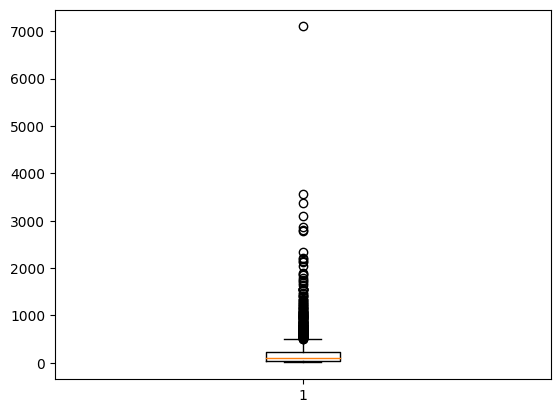

count    1968.000000
mean      212.110264
std       357.872346
min         6.000000
25%        44.000000
50%       105.000000
75%       230.000000
max      7102.000000
Name: preprocessed_text, dtype: float64
-235.0 509.0


In [10]:
length = df["preprocessed_text"].apply(lambda x: len(x))
plt.boxplot(length)
plt.show()
print(length.describe())
q1 = length.quantile(0.25)
q3 = length.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(lower_bound, upper_bound)

In [11]:
#download the google news word2vec model
import gensim.downloader as api
word2vec_model = api.load('word2vec-google-news-300')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

### Task 4 Deep learning model

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#build the embedding matrix using the top 5000 words
embedding_matrix =[[0] * 300] #this matrix will contain the word embeddings for the top 5000 words #the first row will be the embedding for the padding token which is 0
word_indices = {} #this dictionary will map each word to its index in the embedding matrix, this is needed when we train the neural network, the input to the neural network will be the index of the word in the embedding matrix
idx = 1
for i, word in enumerate(top_5000_words):
    if word in word2vec_model.key_to_index:
        embedding_matrix.append(word2vec_model[word])
        word_indices[word] = idx
        idx += 1
    
    else:
        continue
embedding_matrix = np.array(embedding_matrix)
print(embedding_matrix.shape)


(4791, 300)


In [181]:
#LSTM 
class LSTMClf(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(LSTMClf, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        # self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        # self.embedding.weight.requires_grad = False #freeze the embedding layer
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), padding_idx=0, freeze=True)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, 32)
        self.output = nn.Linear(32, 1)
        self.device = device
        
    def forward(self, x):
        #randomly initialize the hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.lstm(out, (h0, c0))
        out = self.fc(out[:, -1, :]).relu()
        out = self.output(out)
        return out
    

class RNNClf(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(RNNClf, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        self.embedding.weight.requires_grad = False #freeze the embedding layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True) 
        self.fc = nn.Linear(hidden_size, 32)
        self.output = nn.Linear(32, 1)
        self.device = device
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.rnn(out, h0)
        out = self.fc(out[:, -1, :]).relu()
        out = self.output(out)
        return out
    
class CNNClf(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_matrix):
        super(CNNClf, self).__init__()
        self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        self.embedding.weight.requires_grad = False
        
        self.conv1 = nn.Conv1d(input_size, hidden_size, kernel_size=3) #output size = (input_size - kernel_size + 1) = (300 - 3 + 1) = 298 
        
        self.fc = nn.Linear(hidden_size * 298, 64)  # 298 is the output size of the convolutional layer
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        
    def forward(self, x):
        out = self.embedding(x)
        out = self.conv1(out).relu()
        out = out.flatten(1)
        out = self.fc(out).relu()
        out = self.fc2(out).relu()
        out = self.fc3(out)
        return out
    
    
class BiLSTMClf(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(BiLSTMClf, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True) 
        self.fc = nn.Linear(hidden_size * 2, 32)
        self.output = nn.Linear(32, 1)
        self.device = device
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(self.device)
        c0  = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.lstm(out, (h0, c0)) 
        out = self.fc(out[:, -1, :]).relu()
        out = self.output(out)
        return out

In [145]:
def padding(sequence, max_len):
    if len(sequence) <= max_len:
        sequences = [sequence + [0] * (max_len - len(sequence))]
    
    elif len(sequence) > max_len:
        #break sequence into chunks of max_len
        sequences = []
        while len(sequence) > max_len:
            sequences.append(sequence[:max_len])
            sequence = sequence[max_len:]
        #if the last chunk is less than max_len, then pad it with zeros
        if len(sequences[-1]) < max_len and len(sequences[-1]) > 5:
            sequences[-1] += [0] * (max_len - len(sequences[-1]))
    
    for seq in sequences:
        assert len(seq) == max_len
    return sequences
        

In [146]:
def prepare_data(df, word_indices, max_len):
    X = []
    y = []
    for i, row in df.iterrows():
        
        sequence = [word_indices[word] for word in row["preprocessed_text"] if word in word_indices and word in word2vec_model.key_to_index]
        sequences = padding(sequence, max_len)
        X += sequences
        if row["subreddit"] == "climate_science":
            y += [1] * len(sequences)
        else:
            y += [0] * len(sequences)
    
    print(len(X[2]))
    #convert X and y to numpy arrays then to tensors
    X = torch.tensor(X).clone().detach()
    y = torch.tensor(y).float().clone().detach()
    return X, y

In [158]:
#prepare the data  
batch_size = 32
max_len = 100
X, y = prepare_data(df, word_indices, max_len)
num_0_class = len(y) - sum(y)
num_1_class = sum(y)
print(num_0_class, num_1_class)

#Split into 80% training and 10% validation and 10% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
#find number of each class in the training set

#convert the data into data loaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# val_dataset = TensorDataset(X_val, y_val)
# val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

print(len(train_loader), len(test_loader))

for x, y in train_loader:
    print(x.shape, y.shape)
    break

100
tensor(3297.) tensor(836.)
104 26
torch.Size([32, 100]) torch.Size([32])


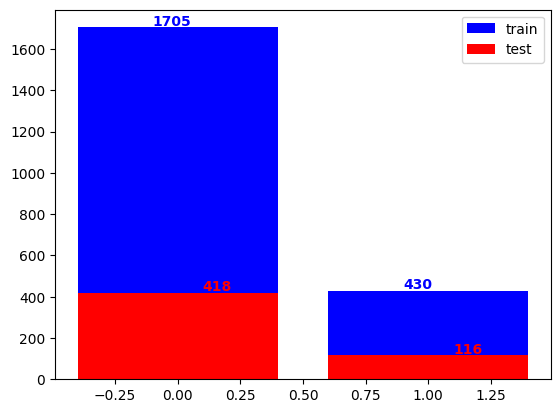

Train class distribution: (tensor([0., 1.]), tensor([1705,  430]))
Test class distribution: (tensor([0., 1.]), tensor([418, 116]))


In [156]:
#plot train data class distribution and test data class distribution
train_class_distribution = y_train.unique(return_counts=True)
test_class_distribution = y_test.unique(return_counts=True)

plt.bar(train_class_distribution[0].numpy(), train_class_distribution[1].numpy(), color='blue', label='train')
plt.bar(test_class_distribution[0].numpy(), test_class_distribution[1].numpy(), color='red', label='test')

# Show the number on the bar
for i, v in enumerate(train_class_distribution[1].numpy()):
    plt.text(train_class_distribution[0][i].item() - 0.1, v + 10, str(v), color='blue', fontweight='bold')
for i, v in enumerate(test_class_distribution[1].numpy()):
    plt.text(test_class_distribution[0][i].item() + 0.1, v + 10, str(v), color='red', fontweight='bold')

plt.legend()
plt.show()

print("Train class distribution:", train_class_distribution)
print("Test class distribution:", test_class_distribution)

In [184]:
def train(train_data, validation_data, criterion, optimizer, device, model, num_epochs):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        train_corr = 0
        total_train = 0

        for x, y in train_data:
            # Send data to the correct device
            x, y = x.to(device), y.to(device).float()
            y = y.unsqueeze(1)  # Ensure y has correct shape for binary classification
            total_train += y.size(0)
            
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item() 

            # Calculate training accuracy
            train_corr += ((output > 0.5).float() == y).sum().item()
            
            loss.backward()
            optimizer.step()
        
        train_losses.append(total_loss / len(train_data))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in validation_data:
                x, y = x.to(device), y.to(device).float()
                y = y.unsqueeze(1)
                output = model(x)
                val_loss += criterion(output, y).item()
            
            val_losses.append(val_loss / len(validation_data))
        
        # Display metrics
        train_accuracy = 100 * train_corr / total_train
        # print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {train_losses[-1]:.4f}, "
        #       f"Train Accuracy: {train_accuracy:.2f}%, Validation Loss: {val_losses[-1]:.4f}")


    return train_losses, val_losses


def test(test_data, model, device):
    model.eval()
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for x, y in test_data:
            x, y = x.to(device), y.to(device).float()
            output = model(x).squeeze(1)
            
            # Collect predictions and true labels as lists of integers
            y_pred.extend((output > 0.5).int().cpu().tolist())
            y_true.extend(y.int().cpu().tolist())

    # Ensure that y_true is the first argument in the metric functions
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1
            

In [185]:
#hyperparameters
input_size = 300
hidden_size = 16
num_layers = 2
num_classes = 1
learning_rate = 0.001
num_epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
criterion = torch.nn.BCEWithLogitsLoss() 


cuda


Training LSTMClf
Test Accuracy: 0.8319, Precision: 0.5797, Recall: 0.2667, F1 Score: 0.3653





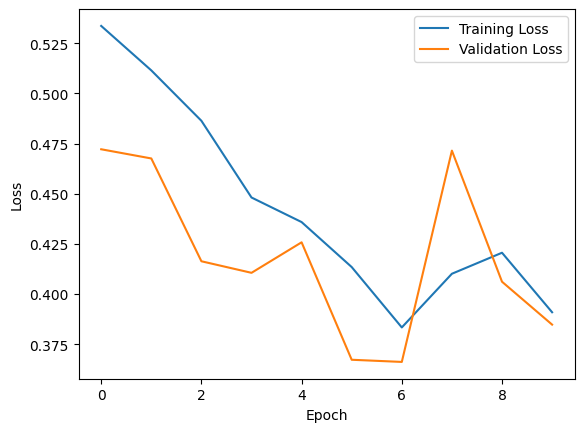

Training CNNClf
Test Accuracy: 0.8525, Precision: 0.6489, Recall: 0.4067, F1 Score: 0.5000





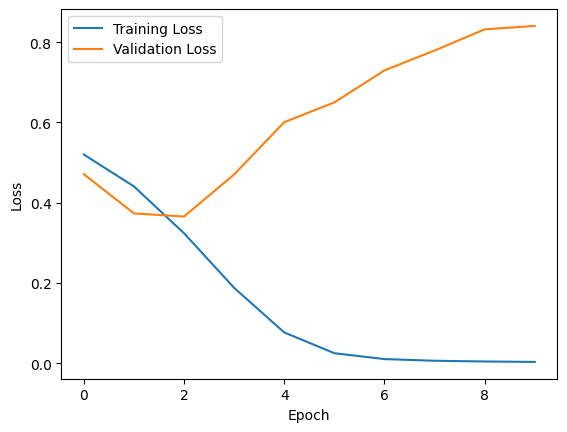

Training RNNClf
Test Accuracy: 0.8174, Precision: 0.4889, Recall: 0.1467, F1 Score: 0.2256





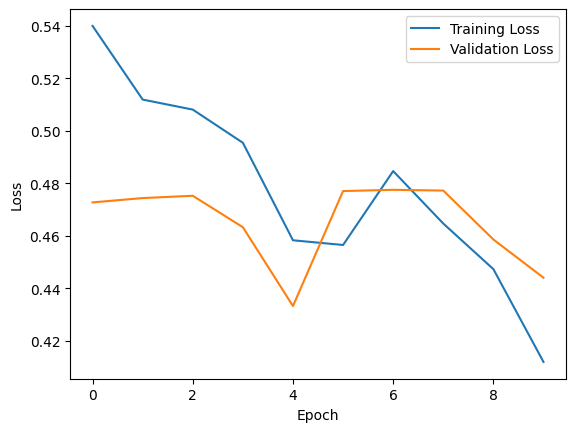

Training BiLSTMClf
Test Accuracy: 0.8295, Precision: 0.5385, Recall: 0.4200, F1 Score: 0.4719





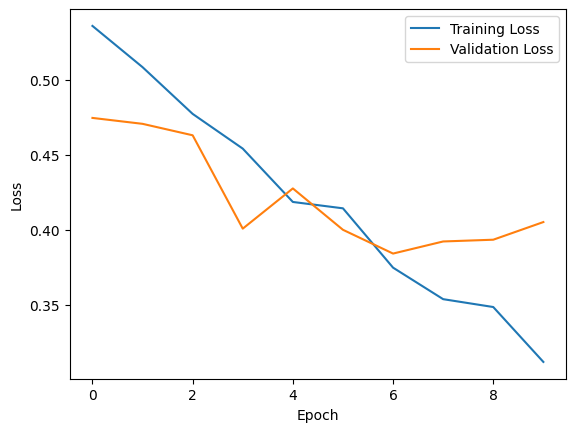

In [187]:
lstm_clf = LSTMClf(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)
rnn_clf = RNNClf(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)
cnn_clf = CNNClf(100, hidden_size, embedding_matrix).to(device)
bi_lstm_clf = BiLSTMClf(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)

#optimizer
models = [lstm_clf, cnn_clf, rnn_clf, bi_lstm_clf]
dl_results = {}
for model in models:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) 
    print(f"Training {model.__class__.__name__}")
    train_losses, val_losses = train(train_loader, test_loader, criterion, optimizer, device, model, num_epochs)
    accuracy, precision, recall, f1 = test(test_loader, model, device)
    dl_results[model.__class__.__name__] = {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
    print("\n\n")
    #plot the training and validation losses
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.show()

In [188]:
print(json.dumps(dl_results, indent=4))


{
    "LSTMClf": {
        "accuracy": 0.8319226118500604,
        "precision": 0.5797101449275363,
        "recall": 0.26666666666666666,
        "f1": 0.36529680365296796
    },
    "CNNClf": {
        "accuracy": 0.8524788391777509,
        "precision": 0.648936170212766,
        "recall": 0.4066666666666667,
        "f1": 0.5
    },
    "RNNClf": {
        "accuracy": 0.8174123337363967,
        "precision": 0.4888888888888889,
        "recall": 0.14666666666666667,
        "f1": 0.22564102564102564
    },
    "BiLSTMClf": {
        "accuracy": 0.8295042321644498,
        "precision": 0.5384615384615384,
        "recall": 0.42,
        "f1": 0.4719101123595505
    }
}
